In [602]:
import pandas as pd
import matplotlib.pyplot as plt

MODES = [
    "noisy_vanilla",
    "cut_divided_budget",
    "cut_qubit_prop",
    "cut_incremental_budget",
    #"cut_incremental_full_budget_per_variant",
    "cut_incremental_qubit_prop",
]

plt.rcParams["figure.figsize"] = (8, 5)

In [603]:
from pathlib import Path
from glob import glob
import re

# csv_path = "/home/local/ADUNIPI/a044855/newcutandinc/results/new/ewma_20k_torino_02/05_qubits/summary.csv"
# csv_path = "/home/local/ADUNIPI/a044855/newcutandinc/results/new/ewma_20k_torino_paper/05_qubits/summary.csv"
#"/home/local/ADUNIPI/a044855/newcutandinc/results/new/ewma_20k_sherbrooke_paper/05_qubits/summary.csv"
#results/new/ewma_20k_sherbrooke_01
#results/new/ewma_20k_kyoto_01

simulators = ["ewma_20k_torino_01", "ewma_20k_sherbrooke_01", "ewma_20k_kyoto_01", "ewma_10k_torino_01","ewma_10k_sherbrooke_01"]
qbits = [10, 11, 12, 13, 14, 15, 16]
base_path = "/home/local/ADUNIPI/a044855/newcutandinc/results/new"

candidate_csv_paths = []

for sim in simulators:
    for q in qbits:
        path = Path(base_path) / sim / f"{q}_qubits" / "summary.csv"
        if not path.exists():
            print(f"Warning: File not found: {path}")
            continue
        candidate_csv_paths.append(path)


def resolve_csv_paths(csv_path):
    inputs = [csv_path] if isinstance(csv_path, (str, Path)) else list(csv_path)

    resolved = []
    for item in inputs:
        item = str(item)

        if any(char in item for char in ["*", "?", "["]):
            matches = sorted(glob(item))
            if not matches:
                raise FileNotFoundError(f"No files matched pattern: {item}")
            resolved.extend(matches)
        else:
            if not Path(item).exists():
                raise FileNotFoundError(f"File not found: {item}")
            resolved.append(item)

    return list(dict.fromkeys(resolved))


def budget_from_path(path):
    """
    Extract budget from simulator folder name.

    Examples:
      ewma_20k_torino_01      -> 20000
      ewma_10k_torino_01      -> 10000
      ewma_5k_torino_01       -> 5000
      ewma_1k_torino_01       -> 1000
      ewma_20k_sherbrooke_01  -> 20000
    """
    path = Path(path)

    # path structure:
    # ... / ewma_20k_torino_01 / 10_qubits / summary.csv
    sim_name = path.parent.parent.name

    match = re.search(r"ewma_(\d+)k_", sim_name)
    if match is None:
        raise ValueError(f"Could not extract budget from simulator name: {sim_name}")

    return int(match.group(1)) * 1000


csv_paths = resolve_csv_paths(candidate_csv_paths)

print("Actually loading CSV paths:")
print("\n".join(map(str, csv_paths)))

dfs = []

for path in csv_paths:
    path = Path(path)

    tmp = pd.read_csv(path)

    # Always take budget from the path, not from shots_requested
    tmp["budget"] = budget_from_path(path)

    # Optional, useful for debugging/grouping later
    tmp["source_simulator"] = path.parent.parent.name
    tmp["source_qubits"] = path.parent.name

    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)
df = df.drop_duplicates().reset_index(drop=True)

required_cols = {
    "circuit_name",
    "mode",
    "absolute_error",
    "shots_executed",
    "budget",
}

missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

df = df[df["mode"].isin(MODES)].copy()
df

Actually loading CSV paths:
/home/local/ADUNIPI/a044855/newcutandinc/results/new/ewma_20k_torino_01/10_qubits/summary.csv
/home/local/ADUNIPI/a044855/newcutandinc/results/new/ewma_20k_torino_01/11_qubits/summary.csv
/home/local/ADUNIPI/a044855/newcutandinc/results/new/ewma_20k_torino_01/12_qubits/summary.csv
/home/local/ADUNIPI/a044855/newcutandinc/results/new/ewma_20k_torino_01/13_qubits/summary.csv
/home/local/ADUNIPI/a044855/newcutandinc/results/new/ewma_20k_torino_01/14_qubits/summary.csv
/home/local/ADUNIPI/a044855/newcutandinc/results/new/ewma_20k_torino_01/15_qubits/summary.csv
/home/local/ADUNIPI/a044855/newcutandinc/results/new/ewma_20k_torino_01/16_qubits/summary.csv
/home/local/ADUNIPI/a044855/newcutandinc/results/new/ewma_20k_sherbrooke_01/10_qubits/summary.csv
/home/local/ADUNIPI/a044855/newcutandinc/results/new/ewma_20k_sherbrooke_01/11_qubits/summary.csv
/home/local/ADUNIPI/a044855/newcutandinc/results/new/ewma_20k_sherbrooke_01/12_qubits/summary.csv
/home/local/ADUNIPI/

,circuit_name,circuit_qubits,observable,mode,backend,perf_exp_val,result,absolute_error,distance_to_noisy_vanilla,time_total_s,...,total_allocated_variant_shots,total_executed_variant_shots,min_allocated_shots_per_variant,max_allocated_shots_per_variant,min_executed_shots_per_variant,max_executed_shots_per_variant,executed_shots_per_variant,budget,source_simulator,source_qubits
0,0_Clifford+T_001,10,ZIIIIIIIII,cut_divided_budget,aer.fake_torino,-1.0,-0.650606,0.349394,0.015194,131.378788,...,20000.0,20000.0,625.0,625.0,625.0,625.0,[625-625-625-625-625-625-625-625-625-625-625-6...,20000,ewma_20k_torino_01,10_qubits
1,0_Clifford+T_001,10,ZIIIIIIIII,cut_incremental_budget,aer.fake_torino,-1.0,-0.672581,0.327419,0.006781,1823.407193,...,20000.0,20000.0,625.0,625.0,625.0,625.0,[625-625-625-625-625-625-625-625-625-625-625-6...,20000,ewma_20k_torino_01,10_qubits
2,0_Clifford+T_001,10,ZIIIIIIIII,cut_incremental_qubit_prop,aer.fake_torino,-1.0,-0.757373,0.242627,0.091573,1914.625270,...,20000.0,20000.0,313.0,937.0,313.0,937.0,[313-313-313-313-313-313-313-313-313-313-313-3...,20000,ewma_20k_torino_01,10_qubits
3,0_Clifford+T_001,10,ZIIIIIIIII,cut_qubit_prop,aer.fake_torino,-1.0,-0.642016,0.357984,0.023784,132.890293,...,20000.0,20000.0,313.0,937.0,313.0,937.0,[313-313-313-313-313-313-313-313-313-313-313-3...,20000,ewma_20k_torino_01,10_qubits
4,0_Clifford+T_001,10,ZIIIIIIIII,noisy_vanilla,aer.fake_torino,-1.0,-0.665800,0.334200,0.665800,4.360980,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20000,ewma_20k_torino_01,10_qubits
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1745,9_Clifford+T_040,16,ZIIIIIIIIIIIIIII,cut_divided_budget,aer.fake_sherbrooke,0.0,0.034995,0.034995,0.028595,21.064817,...,10000.0,10000.0,1250.0,1250.0,1250.0,1250.0,[1250-1250-1250-1250-1250-1250-1250-1250],10000,ewma_10k_sherbrooke_01,16_qubits
1746,9_Clifford+T_040,16,ZIIIIIIIIIIIIIII,cut_incremental_budget,aer.fake_sherbrooke,0.0,-0.033980,0.033980,0.040380,199.138075,...,10000.0,6750.0,1250.0,1250.0,400.0,1250.0,[1250-1250-1250-1250-400-400-500-450],10000,ewma_10k_sherbrooke_01,16_qubits
1747,9_Clifford+T_040,16,ZIIIIIIIIIIIIIII,cut_incremental_qubit_prop,aer.fake_sherbrooke,0.0,0.023984,0.023984,0.017584,279.133942,...,10000.0,9983.0,333.0,2167.0,333.0,2167.0,[2150-2167-2167-2167-333-333-333-333],10000,ewma_10k_sherbrooke_01,16_qubits
1748,9_Clifford+T_040,16,ZIIIIIIIIIIIIIII,cut_qubit_prop,aer.fake_sherbrooke,0.0,-0.013133,0.013133,0.019533,13.877059,...,10000.0,10000.0,333.0,2167.0,333.0,2167.0,[2167-2167-2167-2167-333-333-333-333],10000,ewma_10k_sherbrooke_01,16_qubits


In [604]:
#print df rows with circuit_qubits ==10
df2 = df[df["circuit_qubits"] == 10]
print(df2[["circuit_name", "mode", "absolute_error", "shots_executed", "budget"]])

          circuit_name                        mode  absolute_error  \
0     0_Clifford+T_001          cut_divided_budget        0.349394   
1     0_Clifford+T_001      cut_incremental_budget        0.327419   
2     0_Clifford+T_001  cut_incremental_qubit_prop        0.242627   
3     0_Clifford+T_001              cut_qubit_prop        0.357984   
4     0_Clifford+T_001               noisy_vanilla        0.334200   
...                ...                         ...             ...   
1445  9_Clifford+T_041          cut_divided_budget        0.037893   
1446  9_Clifford+T_041      cut_incremental_budget        0.068226   
1447  9_Clifford+T_041  cut_incremental_qubit_prop        0.038920   
1448  9_Clifford+T_041              cut_qubit_prop        0.044228   
1449  9_Clifford+T_041               noisy_vanilla        0.022400   

      shots_executed  budget  
0              20000   20000  
1              20000   20000  
2              20000   20000  
3              20000   20000  
4   

In [605]:
if "circuit_qubits" not in df.columns:
    raise ValueError("Missing required column: 'size'")

df["circuit_label"] = df["circuit_name"] + "(" + df["circuit_qubits"].astype(str) + ")"
df[["circuit_name", "circuit_qubits", "circuit_label"]].head()

,circuit_name,circuit_qubits,circuit_label
0,0_Clifford+T_001,10,0_Clifford+T_001(10)
1,0_Clifford+T_001,10,0_Clifford+T_001(10)
2,0_Clifford+T_001,10,0_Clifford+T_001(10)
3,0_Clifford+T_001,10,0_Clifford+T_001(10)
4,0_Clifford+T_001,10,0_Clifford+T_001(10)


In [606]:
COMPARE_MODES = [
    "noisy_vanilla",
    "cut_divided_budget",
    "cut_incremental_budget",
    "cut_incremental_full_budget_per_variant",
]

COMPARE_MODES = MODES

needed = {"circuit_qubits", "mode", "absolute_error", "shots_executed"}
missing = needed - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

df_compare = df.copy()

# If your main df was previously filtered to only 3 modes, reload or re-filter from the original CSV
if not set(["noisy_vanilla"]).issubset(set(df_compare["mode"].unique())):
    df_compare = pd.read_csv(csv_path)

if "circuit_label" not in df_compare.columns and "circuit_qubits" in df_compare.columns:
    df_compare["circuit_label"] = (
        df_compare["circuit_name"] + "(" + df_compare["circuit_qubits"].astype(str) + ")"
    )

df_compare = df_compare[df_compare["mode"].isin(COMPARE_MODES)].copy()

grouped = (
    df_compare.groupby(["circuit_qubits", "mode"])[["absolute_error", "shots_executed"]]
    .mean()
    .reset_index()
)

summary_by_size = grouped.pivot(
    index="circuit_qubits",
    columns="mode",
    values=["absolute_error", "shots_executed"],
)

summary_by_size = summary_by_size.sort_index()
summary_by_size

absolute_error                         \
mode           cut_divided_budget cut_incremental_budget   
circuit_qubits                                             
10                       0.092074               0.092108   
11                       0.073951               0.078244   
12                       0.056494               0.052099   
13                       0.106293               0.108095   
14                       0.091514               0.090361   
15                       0.091588               0.091908   
16                       0.097153               0.100858   

                                                                        \
mode           cut_incremental_qubit_prop cut_qubit_prop noisy_vanilla   
circuit_qubits                                                           
10                               0.094998       0.092119      0.143218   
11                               0.088176       0.079202      0.109050   
12                               0.052367       0.055859      0.107566   
13                               0.102640       0.104188      0.129320   
14                               0.092924       0.089996      0.164880   
15                               0.101003       0.092077      0.144202   
16                               0.096682       0.093901      0.166518   

                   shots_executed                         \
mode           cut_divided_budget cut_incremental_budget   
circuit_qubits                                             
10                        16000.0                11971.5   
11                        16000.0                 8962.0   
12                        16000.0                10473.0   
13                        16000.0                 8321.5   
14                        16000.0                 8666.0   
15                        16000.0                 9199.5   
16                        16000.0                 8394.0   

                                                                        
mode           cut_incremental_qubit_prop cut_qubit_prop noisy_vanilla  
circuit_qubits                                                          
10                               12386.14        16000.0       16000.0  
11                                9323.86        16000.0       16000.0  
12                               10701.74        16000.0       16000.0  
13                                8425.26        16000.0       16000.0  
14                                9082.46        16000.0       16000.0  
15                                9691.60        16000.0       16000.0  
16                                8983.92        16000.0       16000.0

In [607]:
print("Rows:", len(df))
print("Modes found:", sorted(df["mode"].unique()))
print("Circuits:", df["circuit_name"].nunique())

Rows: 1750
Modes found: ['cut_divided_budget', 'cut_incremental_budget', 'cut_incremental_qubit_prop', 'cut_qubit_prop', 'noisy_vanilla']
Circuits: 58


In [608]:
summary = (
    df.groupby("mode")[["absolute_error", "shots_executed"]]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(10)
)

summary

absolute_error                                \
                                    count      mean    median       std   
mode                                                                      
cut_divided_budget                    350  0.087009  0.036312  0.121785   
cut_incremental_budget                350  0.087668  0.038532  0.119290   
cut_incremental_qubit_prop            350  0.089827  0.041905  0.119776   
cut_qubit_prop                        350  0.086763  0.036860  0.121733   
noisy_vanilla                         350  0.137822  0.023400  0.152440   

                                               shots_executed                \
                                 min       max          count          mean   
mode                                                                          
cut_divided_budget          0.000044  0.617441            350  16000.000000   
cut_incremental_budget      0.000000  0.568731            350   9426.785714   
cut_incremental_qubit_prop  0.000000  0.561498            350   9799.282857   
cut_qubit_prop              0.000061  0.552549            350  16000.000000   
noisy_vanilla               0.000000  0.350600            350  16000.000000   

                                                                
                             median          std    min    max  
mode                                                            
cut_divided_budget          20000.0  4905.993060  10000  20000  
cut_incremental_budget       7975.0  4314.080617   1600  20000  
cut_incremental_qubit_prop   8850.0  4443.516889   1650  20000  
cut_qubit_prop              20000.0  4905.993060  10000  20000  
noisy_vanilla               20000.0  4905.993060  10000  20000

In [609]:
error_pivot = (
    df.pivot_table(
        index="circuit_label",
        columns="mode",
        values="absolute_error",
        aggfunc="first",
    )
    .dropna(subset=MODES)
    .reindex(columns=MODES)
)

shots_pivot = (
    df.pivot_table(
        index="circuit_label",
        columns="mode",
        values="shots_executed",
        aggfunc="first",
    )
    .dropna(subset=MODES)
    .reindex(columns=MODES)
)

error_pivot.head(), shots_pivot.head()

(mode                  noisy_vanilla  cut_divided_budget  cut_qubit_prop  \
 circuit_label                                                             
 0_Clifford+T_001(10)         0.3342            0.349394        0.357984   
 0_Clifford+T_001(11)         0.0087            0.011505        0.002225   
 0_Clifford+T_001(12)         0.0065            0.013290        0.007106   
 0_Clifford+T_001(14)         0.3215            0.016522        0.018600   
 0_Clifford+T_002(13)         0.3409            0.090022        0.109856   
 
 mode                  cut_incremental_budget  cut_incremental_qubit_prop  
 circuit_label                                                             
 0_Clifford+T_001(10)                0.327419                    0.242627  
 0_Clifford+T_001(11)                0.037163                    0.002191  
 0_Clifford+T_001(12)                0.014702                    0.004161  
 0_Clifford+T_001(14)                0.010441                    0.016576  
 0_Cliffor

In [610]:
error_winners = error_pivot.idxmin(axis=1).value_counts().reindex(MODES, fill_value=0)
shots_winners = shots_pivot.idxmin(axis=1).value_counts().reindex(MODES, fill_value=0)

print("Absolute error winner counts:")
display(error_winners.to_frame("wins"))

print("\nShots executed winner counts:")
display(shots_winners.to_frame("wins"))

Absolute error winner counts:


,wins
noisy_vanilla,8
cut_divided_budget,11
cut_qubit_prop,14
cut_incremental_budget,18
cut_incremental_qubit_prop,19



Shots executed winner counts:


,wins
noisy_vanilla,5
cut_divided_budget,0
cut_qubit_prop,0
cut_incremental_budget,34
cut_incremental_qubit_prop,31


In [611]:
def pairwise_wins(pivot, modes=MODES):
    rows = []
    for i in range(len(modes)):
        for j in range(i + 1, len(modes)):
            a = modes[i]
            b = modes[j]
            rows.append({
                "mode_a": a,
                "mode_b": b,
                "a_wins": (pivot[a] < pivot[b]).sum(),
                "b_wins": (pivot[b] < pivot[a]).sum(),
                "ties": (pivot[a] == pivot[b]).sum(),
            })
    return pd.DataFrame(rows)

print("Pairwise wins for absolute_error:")
display(pairwise_wins(error_pivot))

print("Pairwise wins for shots_executed:")
display(pairwise_wins(shots_pivot))

Pairwise wins for absolute_error:


,mode_a,mode_b,a_wins,b_wins,ties
0,noisy_vanilla,cut_divided_budget,18,52,0
1,noisy_vanilla,cut_qubit_prop,17,53,0
2,noisy_vanilla,cut_incremental_budget,24,46,0
3,noisy_vanilla,cut_incremental_qubit_prop,21,49,0
4,cut_divided_budget,cut_qubit_prop,32,38,0
5,cut_divided_budget,cut_incremental_budget,40,30,0
6,cut_divided_budget,cut_incremental_qubit_prop,36,34,0
7,cut_qubit_prop,cut_incremental_budget,35,35,0
8,cut_qubit_prop,cut_incremental_qubit_prop,41,29,0
9,cut_incremental_budget,cut_incremental_qubit_prop,41,29,0


Pairwise wins for shots_executed:


,mode_a,mode_b,a_wins,b_wins,ties
0,noisy_vanilla,cut_divided_budget,0,0,70
1,noisy_vanilla,cut_qubit_prop,0,0,70
2,noisy_vanilla,cut_incremental_budget,0,65,5
3,noisy_vanilla,cut_incremental_qubit_prop,0,59,11
4,cut_divided_budget,cut_qubit_prop,0,0,70
5,cut_divided_budget,cut_incremental_budget,0,65,5
6,cut_divided_budget,cut_incremental_qubit_prop,0,59,11
7,cut_qubit_prop,cut_incremental_budget,0,65,5
8,cut_qubit_prop,cut_incremental_qubit_prop,0,59,11
9,cut_incremental_budget,cut_incremental_qubit_prop,31,31,8


In [612]:
df_eff = df.copy()
df_eff["error_per_1k_shots"] = df_eff["absolute_error"] / (df_eff["shots_executed"] / 1000.0)

eff_summary = (
    df_eff.groupby("mode")["error_per_1k_shots"]
    .agg(["mean", "median", "std", "min", "max"])
    .round(10)
)

eff_summary

,mean,median,std,min,max
mode,,,,,
cut_divided_budget,0.005993,0.002479,0.008961,0.000002,0.054526
cut_incremental_budget,0.010270,0.004537,0.014158,0.000000,0.078151
cut_incremental_qubit_prop,0.010090,0.004557,0.013745,0.000000,0.077986
cut_qubit_prop,0.006043,0.002407,0.009006,0.000003,0.054689
noisy_vanilla,0.009281,0.002200,0.011307,0.000000,0.035060


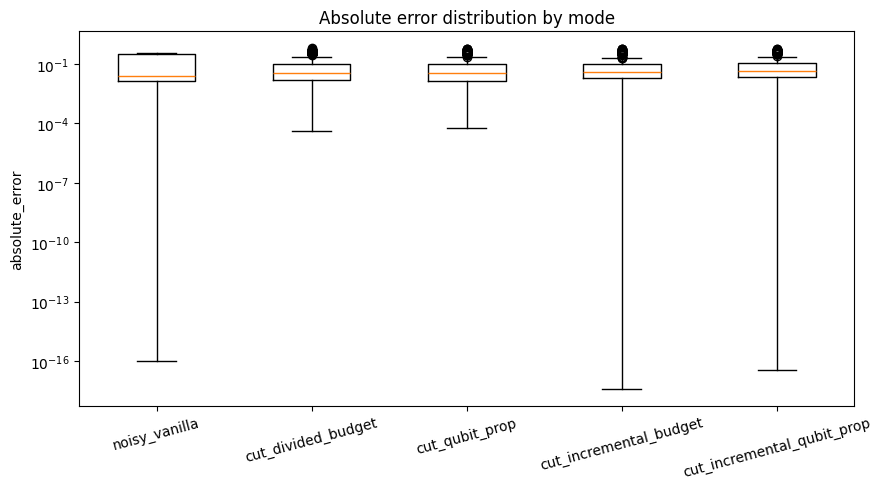

In [613]:
plt.figure(figsize=(9, 5))
data = [df.loc[df["mode"] == mode, "absolute_error"].values for mode in MODES]
plt.boxplot(data, tick_labels=MODES)
plt.yscale("log")
plt.ylabel("absolute_error")
plt.title("Absolute error distribution by mode")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

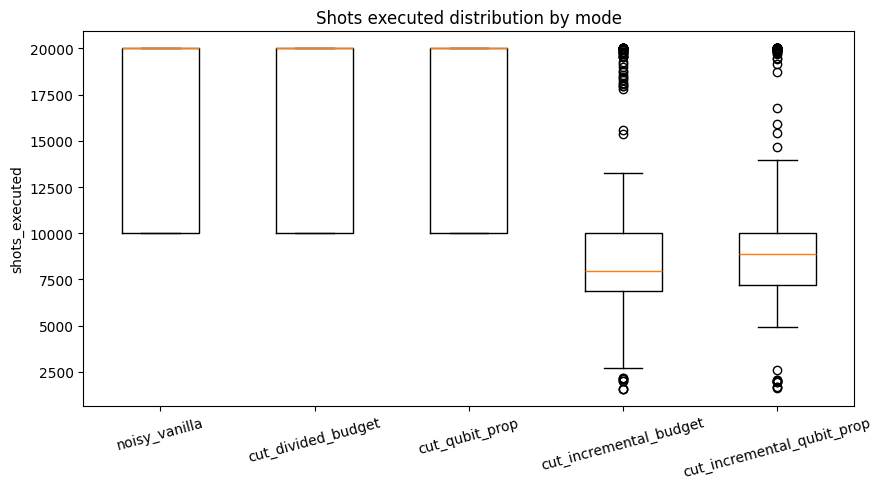

In [614]:
plt.figure(figsize=(9, 5))
data = [df.loc[df["mode"] == mode, "shots_executed"].values for mode in MODES]
plt.boxplot(data, tick_labels=MODES)
plt.ylabel("shots_executed")
plt.title("Shots executed distribution by mode")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

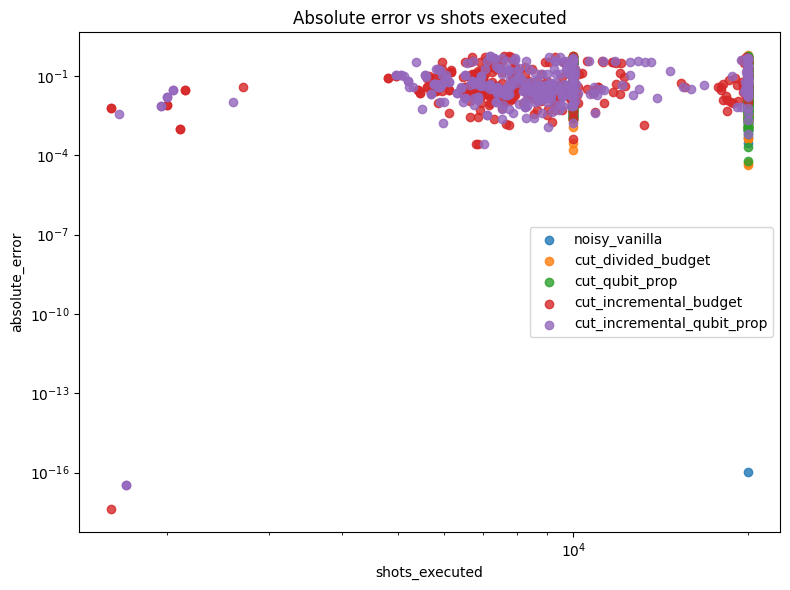

In [615]:
plt.figure(figsize=(8, 6))

for mode in MODES:
    sub = df[df["mode"] == mode]
    plt.scatter(sub["shots_executed"], sub["absolute_error"], label=mode, alpha=0.8)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("shots_executed")
plt.ylabel("absolute_error")
plt.title("Absolute error vs shots executed")
plt.legend()
plt.tight_layout()
plt.show()

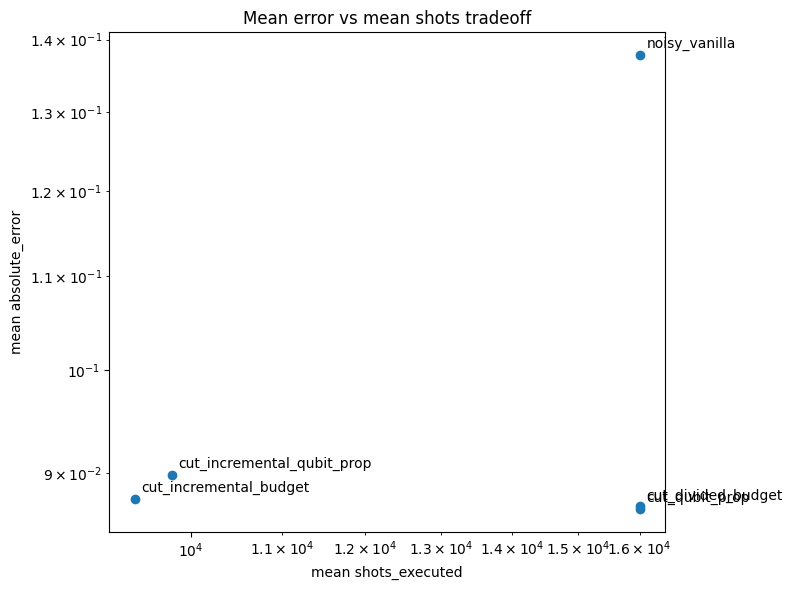

,shots_executed,absolute_error
mode,,
noisy_vanilla,16000.000000,0.137822
cut_divided_budget,16000.000000,0.087009
cut_qubit_prop,16000.000000,0.086763
cut_incremental_budget,9426.785714,0.087668
cut_incremental_qubit_prop,9799.282857,0.089827


In [616]:
mean_tradeoff = (
    df.groupby("mode")[["shots_executed", "absolute_error"]]
    .mean()
    .reindex(MODES)
)

plt.figure(figsize=(8, 6))
plt.scatter(mean_tradeoff["shots_executed"], mean_tradeoff["absolute_error"])

for mode, row in mean_tradeoff.iterrows():
    plt.annotate(
        mode,
        (row["shots_executed"], row["absolute_error"]),
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("mean shots_executed")
plt.ylabel("mean absolute_error")
plt.title("Mean error vs mean shots tradeoff")
plt.tight_layout()
plt.show()

mean_tradeoff

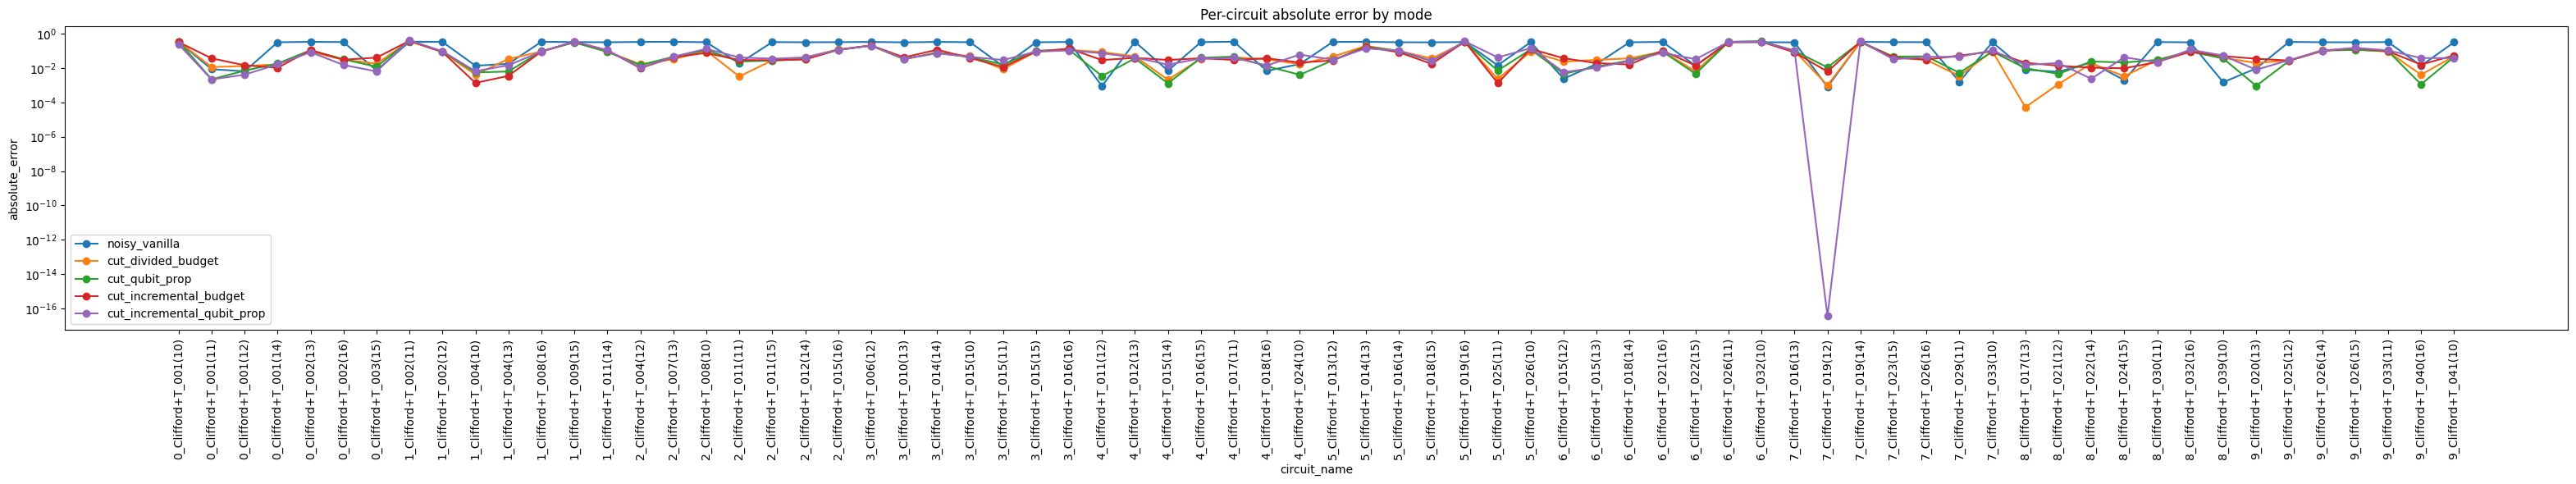

In [617]:
error_plot = error_pivot.sort_index()

plt.figure(figsize=(max(10, len(error_plot) * 0.45), 6))
for mode in MODES:
    plt.plot(error_plot.index, error_plot[mode], marker="o", label=mode)

plt.yscale("log")
plt.xlabel("circuit_name")
plt.ylabel("absolute_error")
plt.title("Per-circuit absolute error by mode")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

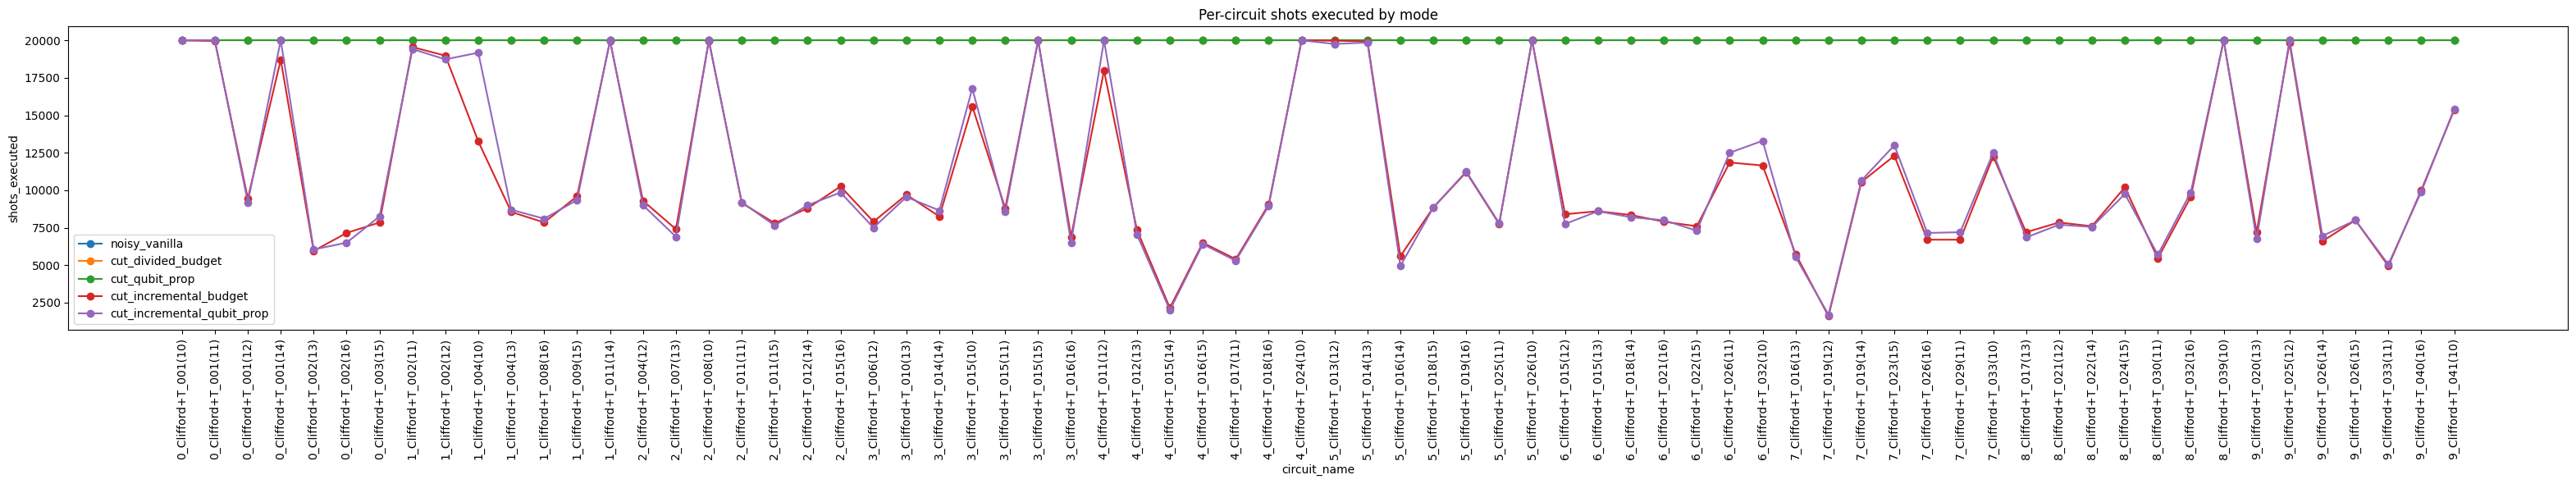

In [618]:
shots_plot = shots_pivot.sort_index()

plt.figure(figsize=(max(10, len(shots_plot) * 0.45), 6))
for mode in MODES:
    plt.plot(shots_plot.index, shots_plot[mode], marker="o", label=mode)

plt.xlabel("circuit_name")
plt.ylabel("shots_executed")
plt.title("Per-circuit shots executed by mode")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

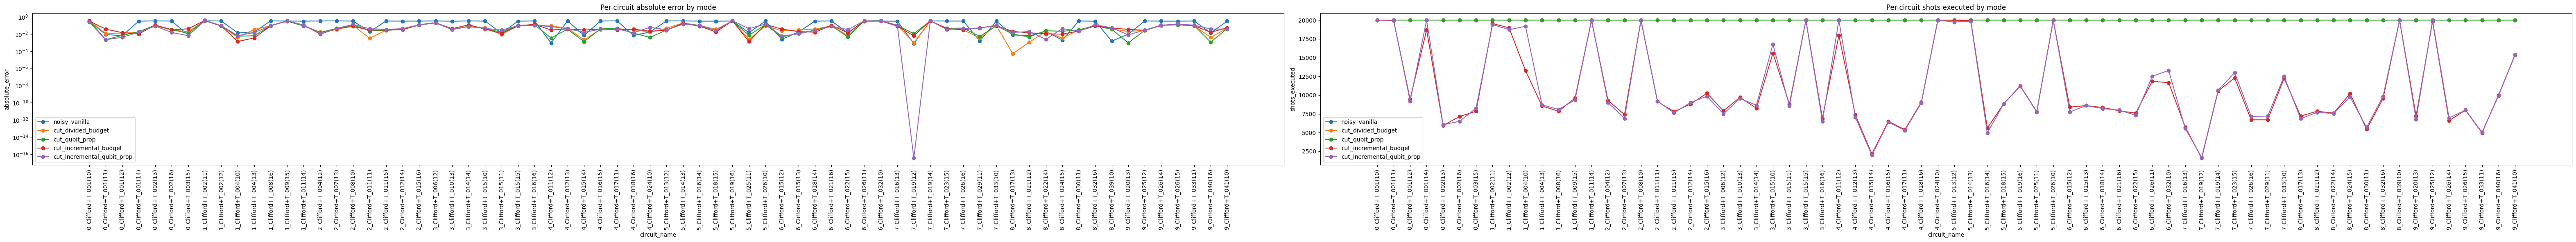

In [619]:
#subplots with the 2 previous plots together side by side
plt.figure(figsize=(max(20, len(error_plot) * 0.9), 6))
plt.subplot(1, 2, 1)
for mode in MODES:
    plt.plot(error_plot.index, error_plot[mode], marker="o", label=mode)
plt.yscale("log")
plt.xlabel("circuit_name")
plt.ylabel("absolute_error")
plt.title("Per-circuit absolute error by mode")
plt.xticks(rotation=90)
plt.legend()
plt.subplot(1, 2, 2)
for mode in MODES:
    plt.plot(shots_plot.index, shots_plot[mode], marker="o", label=mode)
plt.xlabel("circuit_name")
plt.ylabel("shots_executed")
plt.title("Per-circuit shots executed by mode")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()


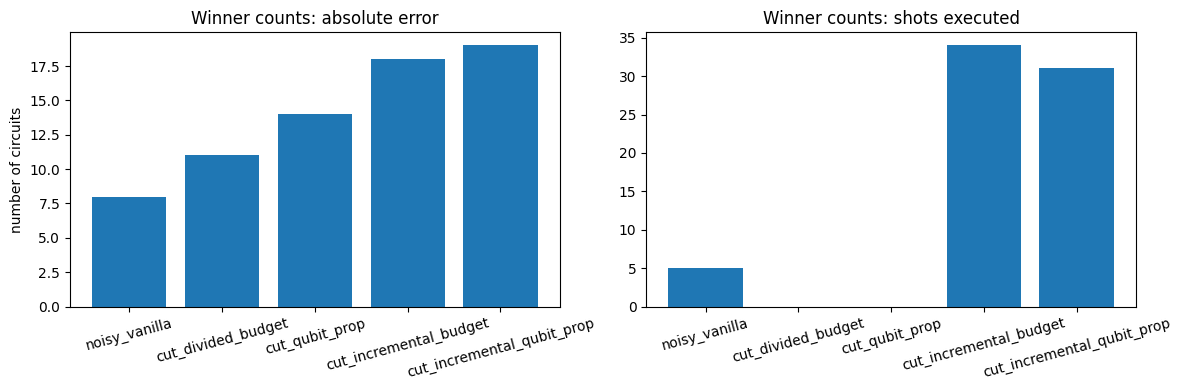

In [620]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(error_winners.index, error_winners.values)
axes[0].set_title("Winner counts: absolute error")
axes[0].set_ylabel("number of circuits")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(shots_winners.index, shots_winners.values)
axes[1].set_title("Winner counts: shots executed")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

In [621]:
final_table = pd.DataFrame({
    "mean_absolute_error": df.groupby("mode")["absolute_error"].mean(),
    "median_absolute_error": df.groupby("mode")["absolute_error"].median(),
    "mean_shots_executed": df.groupby("mode")["shots_executed"].mean(),
    "median_shots_executed": df.groupby("mode")["shots_executed"].median(),
    "absolute_error_wins": error_winners,
    "shots_executed_wins": shots_winners,
    "mean_error_per_1k_shots": df_eff.groupby("mode")["error_per_1k_shots"].mean(),
}).reindex(MODES).round(10)

final_table

,mean_absolute_error,median_absolute_error,mean_shots_executed,median_shots_executed,absolute_error_wins,shots_executed_wins,mean_error_per_1k_shots
noisy_vanilla,0.137822,0.023400,16000.000000,20000.0,8,5,0.009281
cut_divided_budget,0.087009,0.036312,16000.000000,20000.0,11,0,0.005993
cut_qubit_prop,0.086763,0.036860,16000.000000,20000.0,14,0,0.006043
cut_incremental_budget,0.087668,0.038532,9426.785714,7975.0,18,34,0.010270
cut_incremental_qubit_prop,0.089827,0.041905,9799.282857,8850.0,19,31,0.010090


In [622]:
import pandas as pd
import matplotlib.pyplot as plt

result_by_size = pd.DataFrame(index=summary_by_size.index)

def get_metric_or_nan(metric, mode):
    if (metric, mode) in summary_by_size.columns:
        return summary_by_size[(metric, mode)]
    return pd.Series(index=summary_by_size.index, dtype=float)

vanilla_mode = next((m for m in MODES if "vanilla" in m), None)
divided_mode = next((m for m in MODES if "divided" in m), None)

# Base per-mode columns: always create them
for mode in MODES:
    result_by_size[f"shots_{mode}"] = get_metric_or_nan("shots_executed", mode)
    result_by_size[f"error_{mode}"] = get_metric_or_nan("absolute_error", mode)

# Shots saved: every mode vs divided
if divided_mode:
    divided_shots = result_by_size[f"shots_{divided_mode}"]

    for mode in MODES:
        if mode == divided_mode:
            continue

        mode_shots = result_by_size[f"shots_{mode}"]
        result_by_size[f"shots_saved_%_{mode}_vs_{divided_mode}"] = (
            100 * (divided_shots - mode_shots) / divided_shots
        )

# Error comparisons: every mode vs vanilla
if vanilla_mode:
    vanilla_err = result_by_size[f"error_{vanilla_mode}"]

    for mode in MODES:
        if mode == vanilla_mode:
            continue

        mode_err = result_by_size[f"error_{mode}"]
        result_by_size[f"error_ratio_{mode}_vs_{vanilla_mode}"] = mode_err / vanilla_err
        result_by_size[f"error_change_%_{mode}_vs_{vanilla_mode}"] = (
            100 * (mode_err - vanilla_err) / vanilla_err
        )

# Error comparisons: every mode vs divided
if divided_mode:
    divided_err = result_by_size[f"error_{divided_mode}"]

    for mode in MODES:
        if mode == divided_mode:
            continue

        mode_err = result_by_size[f"error_{mode}"]
        result_by_size[f"error_ratio_{mode}_vs_{divided_mode}"] = mode_err / divided_err
        result_by_size[f"error_change_%_{mode}_vs_{divided_mode}"] = (
            100 * (mode_err - divided_err) / divided_err
        )

result_by_size = result_by_size.round(4)

In [623]:
comparison_cols = []

vanilla_mode = next((m for m in MODES if "vanilla" in m), None)
divided_mode = next((m for m in MODES if "divided" in m), None)

if divided_mode:
    comparison_cols.extend(
        f"shots_saved_%_{mode}_vs_{divided_mode}"
        for mode in MODES
        if mode != divided_mode
    )

if vanilla_mode:
    comparison_cols.extend(
        f"{metric}_{mode}_vs_{vanilla_mode}"
        for mode in MODES
        if mode != vanilla_mode
        for metric in ["error_ratio", "error_change_%"]
    )

if divided_mode:
    comparison_cols.extend(
        f"{metric}_{mode}_vs_{divided_mode}"
        for mode in MODES
        if mode != divided_mode
        for metric in ["error_ratio", "error_change_%"]
    )

comparison_table = result_by_size[comparison_cols].round(4)

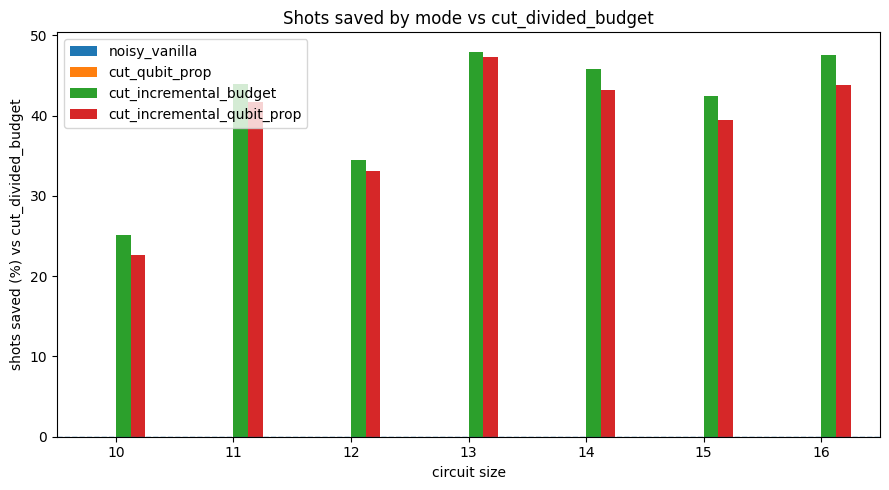

In [624]:
comparison_table = comparison_table.copy()
comparison_table.index = comparison_table.index.astype(int)
comparison_table = comparison_table.sort_index()

divided_mode = next((m for m in MODES if "divided" in m), None)

plot_cols = []
plot_labels = []

if divided_mode:
    for mode in MODES:
        if mode == divided_mode:
            continue
        col = f"shots_saved_%_{mode}_vs_{divided_mode}"
        if col in comparison_table.columns:
            plot_cols.append(col)
            plot_labels.append(mode)

plot_df = comparison_table[plot_cols].copy()
plot_df.columns = plot_labels

ax = plot_df.plot(kind="bar", figsize=(9, 5))
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xlabel("circuit size")
ax.set_ylabel(f"shots saved (%) vs {divided_mode}")
ax.set_title(f"Shots saved by mode vs {divided_mode}")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

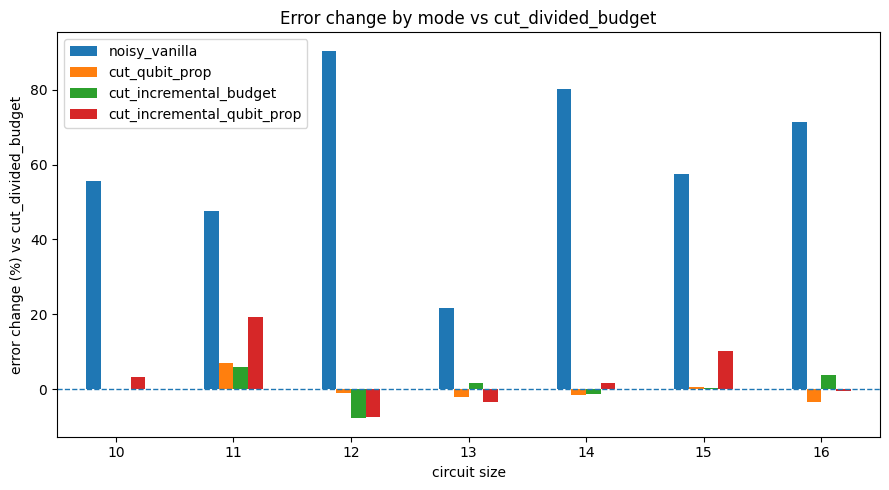

In [625]:
divided_mode = next((m for m in MODES if "divided" in m), None)

plot_cols = []
plot_labels = []

if divided_mode:
    for mode in MODES:
        if mode == divided_mode:
            continue
        col = f"error_change_%_{mode}_vs_{divided_mode}"
        if col in comparison_table.columns:
            plot_cols.append(col)
            plot_labels.append(mode)

plot_df = comparison_table[plot_cols].copy()
plot_df.columns = plot_labels

ax = plot_df.plot(kind="bar", figsize=(9, 5))
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xlabel("circuit size")
ax.set_ylabel(f"error change (%) vs {divided_mode}")
ax.set_title(f"Error change by mode vs {divided_mode}")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

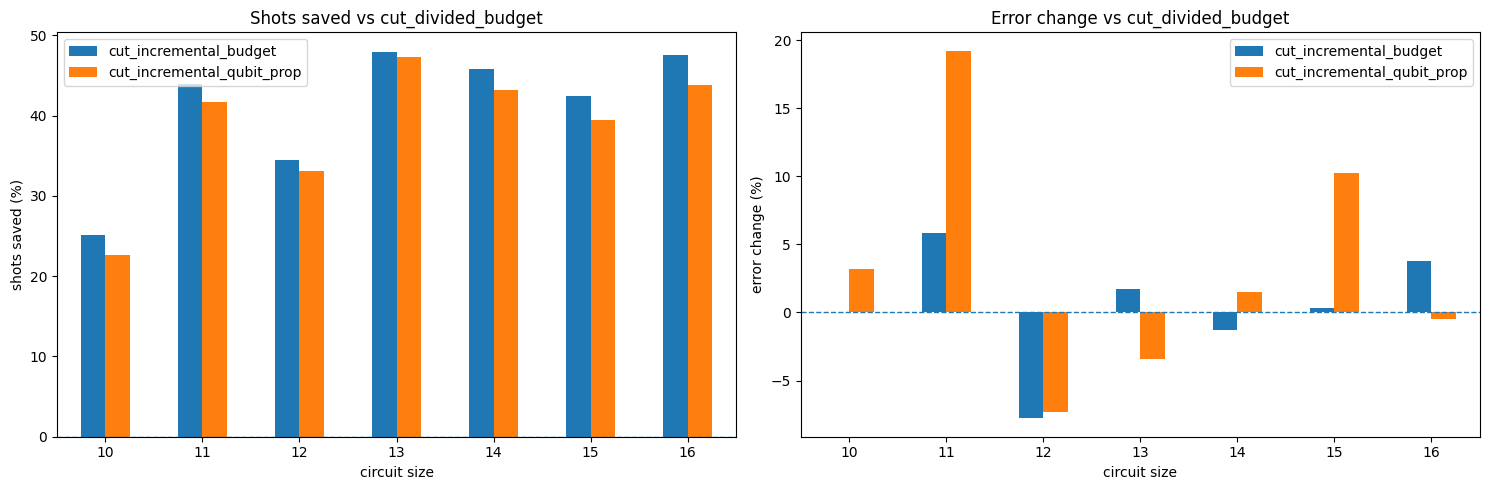

In [626]:
comparison_table = comparison_table.copy()
comparison_table.index = comparison_table.index.astype(int)
comparison_table = comparison_table.sort_index()

divided_mode = next((m for m in MODES if "divided" in m), None)
incremental_modes = [m for m in MODES if "incremental" in m]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left plot: shots saved vs divided
shots_cols = []
shots_labels = []

if divided_mode:
    for inc_mode in incremental_modes:
        col = f"shots_saved_%_{inc_mode}_vs_{divided_mode}"
        if col in comparison_table.columns:
            shots_cols.append(col)
            shots_labels.append(inc_mode)

shots_df = comparison_table[shots_cols].copy()
shots_df.columns = shots_labels

shots_df.plot(kind="bar", ax=axes[0])
axes[0].axhline(0, linestyle="--", linewidth=1)
axes[0].set_xlabel("circuit size")
axes[0].set_ylabel("shots saved (%)")
axes[0].set_title(f"Shots saved vs {divided_mode}")
axes[0].tick_params(axis="x", rotation=0)

# Right plot: error change vs divided
error_cols = []
error_labels = []

if divided_mode:
    for inc_mode in incremental_modes:
        col = f"error_change_%_{inc_mode}_vs_{divided_mode}"
        if col in comparison_table.columns:
            error_cols.append(col)
            error_labels.append(inc_mode)

error_df = comparison_table[error_cols].copy()
error_df.columns = error_labels

error_df.plot(kind="bar", ax=axes[1])
axes[1].axhline(0, linestyle="--", linewidth=1)
axes[1].set_xlabel("circuit size")
axes[1].set_ylabel("error change (%)")
axes[1].set_title(f"Error change vs {divided_mode}")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

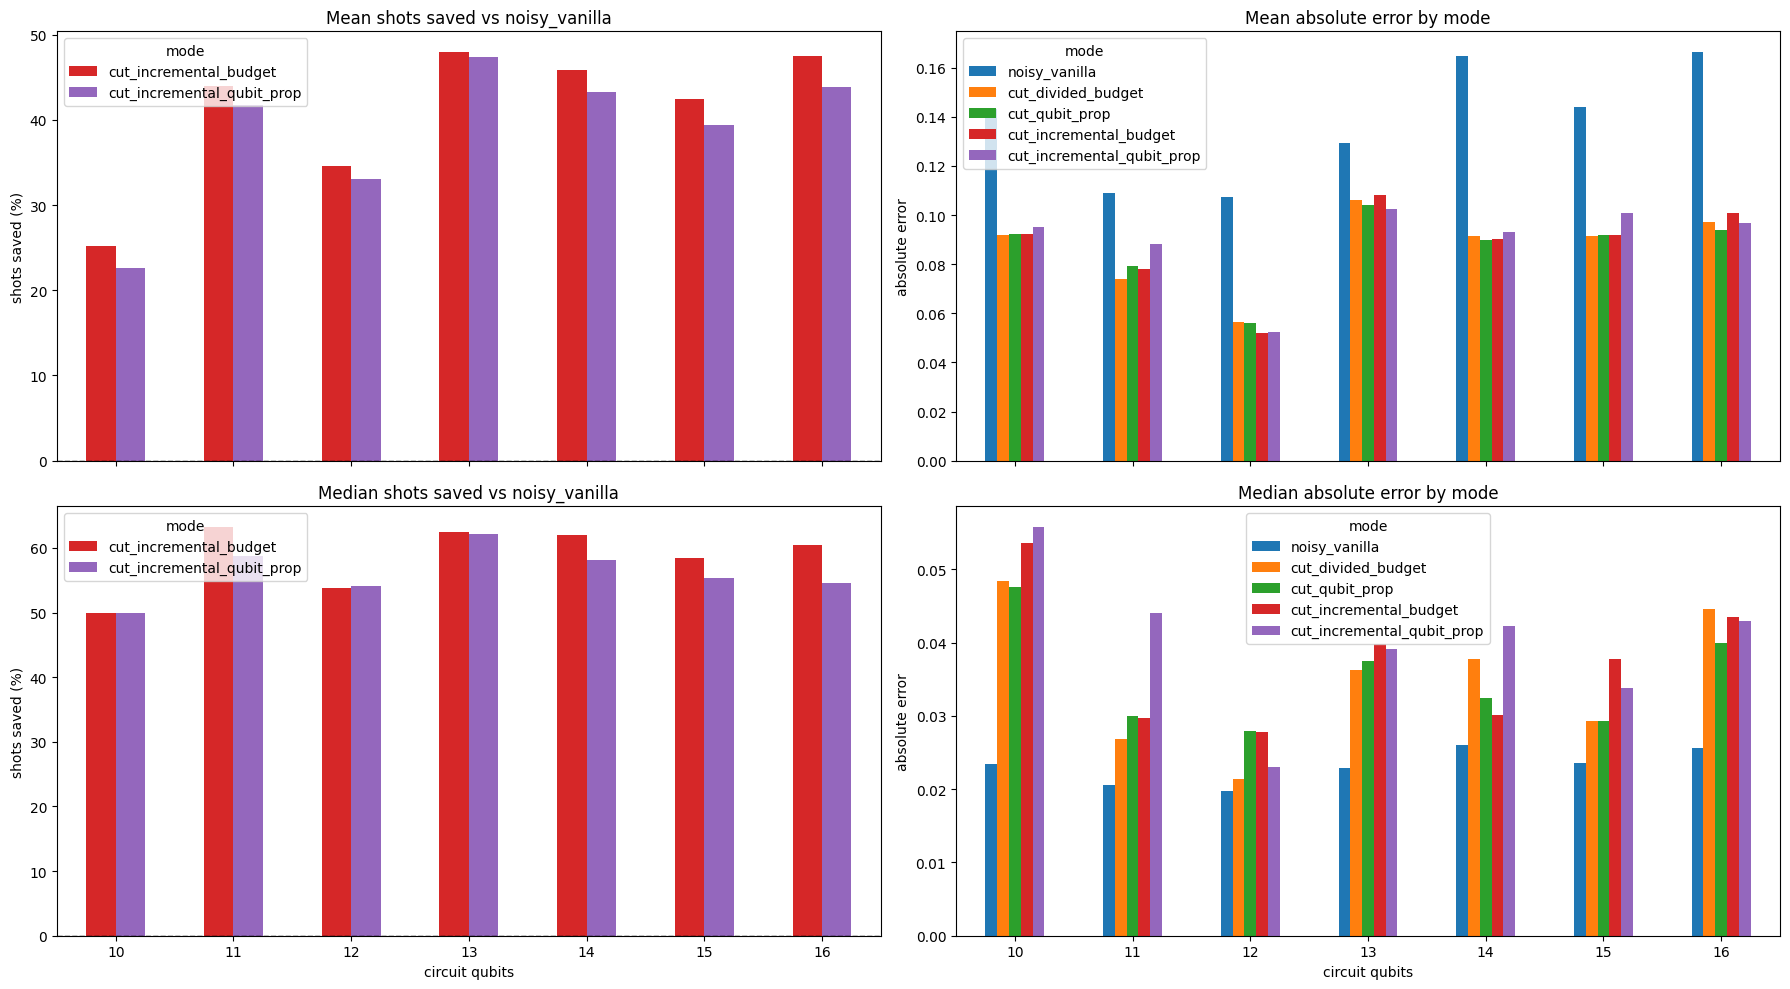

In [627]:
import matplotlib.pyplot as plt
import pandas as pd

# Assumptions:
# - df is already loaded
# - MODES is already defined, for example:
# MODES = [
#     "noisy_vanilla",
#     "cut_divided_budget",
#     "cut_qubit_prop",
#     "cut_incremental_budget",
#     "cut_incremental_qubit_prop",
# ]

baseline_mode = "noisy_vanilla"
size_col = "circuit_qubits"

required_cols = {size_col, "mode", "shots_executed", "absolute_error"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

plot_df = df[df["mode"].isin(MODES)].copy()

if baseline_mode not in plot_df["mode"].unique():
    raise ValueError(f"Baseline mode '{baseline_mode}' not found in df['mode']")

# Only incremental modes for the shots-saved plots
incremental_modes = [m for m in MODES if m != baseline_mode and "incremental" in m]
if not incremental_modes:
    raise ValueError("No incremental modes found in MODES")

# Fixed colors so the same mode has the same color in every plot
color_map = {
    "noisy_vanilla": "tab:blue",
    "cut_divided_budget": "tab:orange",
    "cut_qubit_prop": "tab:green",
    "cut_incremental_budget": "tab:red",
    "cut_incremental_qubit_prop": "tab:purple",
}

# Fallback colors for any mode not explicitly listed above
default_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for i, mode in enumerate(MODES):
    if mode not in color_map:
        color_map[mode] = default_cycle[i % len(default_cycle)]


def build_aggregated_tables(dataframe, agg_func):
    if agg_func not in {"mean", "median"}:
        raise ValueError("agg_func must be 'mean' or 'median'")

    agg_df = (
        dataframe.groupby([size_col, "mode"], as_index=False)
        .agg(
            shots_executed=("shots_executed", agg_func),
            absolute_error=("absolute_error", agg_func),
        )
    )

    shots_pivot = (
        agg_df.pivot(index=size_col, columns="mode", values="shots_executed")
        .reindex(columns=MODES)
        .sort_index()
    )

    error_pivot = (
        agg_df.pivot(index=size_col, columns="mode", values="absolute_error")
        .reindex(columns=MODES)
        .sort_index()
    )

    if baseline_mode not in shots_pivot.columns:
        raise ValueError(f"Baseline mode '{baseline_mode}' not found after aggregation")

    available_incremental_modes = [
        m for m in incremental_modes
        if m in shots_pivot.columns and shots_pivot[m].notna().any()
    ]
    if not available_incremental_modes:
        raise ValueError(f"No incremental modes available for {agg_func} shots plot")

    shots_df = (
        shots_pivot[available_incremental_modes]
        .rsub(shots_pivot[baseline_mode], axis=0)   # baseline - mode
        .div(shots_pivot[baseline_mode], axis=0)    # / baseline
        .mul(100)                                   # percentage
        .sort_index()
    )

    available_error_modes = [
        m for m in MODES
        if m in error_pivot.columns and error_pivot[m].notna().any()
    ]
    if not available_error_modes:
        raise ValueError(f"No modes available for {agg_func} error plot")

    error_df = error_pivot[available_error_modes].abs().sort_index()

    return shots_df, error_df


mean_shots_df, mean_error_df = build_aggregated_tables(plot_df, "mean")
median_shots_df, median_error_df = build_aggregated_tables(plot_df, "median")

fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=True)

# Top-left: mean shots saved
mean_shots_colors = [color_map[m] for m in mean_shots_df.columns]
mean_shots_df.plot(kind="bar", ax=axes[0, 0], color=mean_shots_colors)
axes[0, 0].axhline(0, linestyle="--", linewidth=1, color="black")
axes[0, 0].set_xlabel("circuit qubits")
axes[0, 0].set_ylabel("shots saved (%)")
axes[0, 0].set_title(f"Mean shots saved vs {baseline_mode}")
axes[0, 0].tick_params(axis="x", rotation=0)
axes[0, 0].legend(title="mode")

# Top-right: mean absolute error
mean_error_colors = [color_map[m] for m in mean_error_df.columns]
mean_error_df.plot(kind="bar", ax=axes[0, 1], color=mean_error_colors)
axes[0, 1].set_xlabel("circuit qubits")
axes[0, 1].set_ylabel("absolute error")
axes[0, 1].set_title("Mean absolute error by mode")
axes[0, 1].tick_params(axis="x", rotation=0)
axes[0, 1].legend(title="mode")

# Bottom-left: median shots saved
median_shots_colors = [color_map[m] for m in median_shots_df.columns]
median_shots_df.plot(kind="bar", ax=axes[1, 0], color=median_shots_colors)
axes[1, 0].axhline(0, linestyle="--", linewidth=1, color="black")
axes[1, 0].set_xlabel("circuit qubits")
axes[1, 0].set_ylabel("shots saved (%)")
axes[1, 0].set_title(f"Median shots saved vs {baseline_mode}")
axes[1, 0].tick_params(axis="x", rotation=0)
axes[1, 0].legend(title="mode")

# Bottom-right: median absolute error
median_error_colors = [color_map[m] for m in median_error_df.columns]
median_error_df.plot(kind="bar", ax=axes[1, 1], color=median_error_colors)
axes[1, 1].set_xlabel("circuit qubits")
axes[1, 1].set_ylabel("absolute error")
axes[1, 1].set_title("Median absolute error by mode")
axes[1, 1].tick_params(axis="x", rotation=0)
axes[1, 1].legend(title="mode")

plt.tight_layout()
plt.show()

Aggregation: mean
Whiskers: SEM
Budgets found: ['10k', '20k']
Qubit sizes found: [10, 11, 12, 13, 14, 15, 16]
Modes in shots-saved plot: ['cut_incremental_budget', 'cut_incremental_qubit_prop']
Modes in error plot: ['noisy_vanilla', 'cut_divided_budget', 'cut_qubit_prop', 'cut_incremental_budget', 'cut_incremental_qubit_prop']


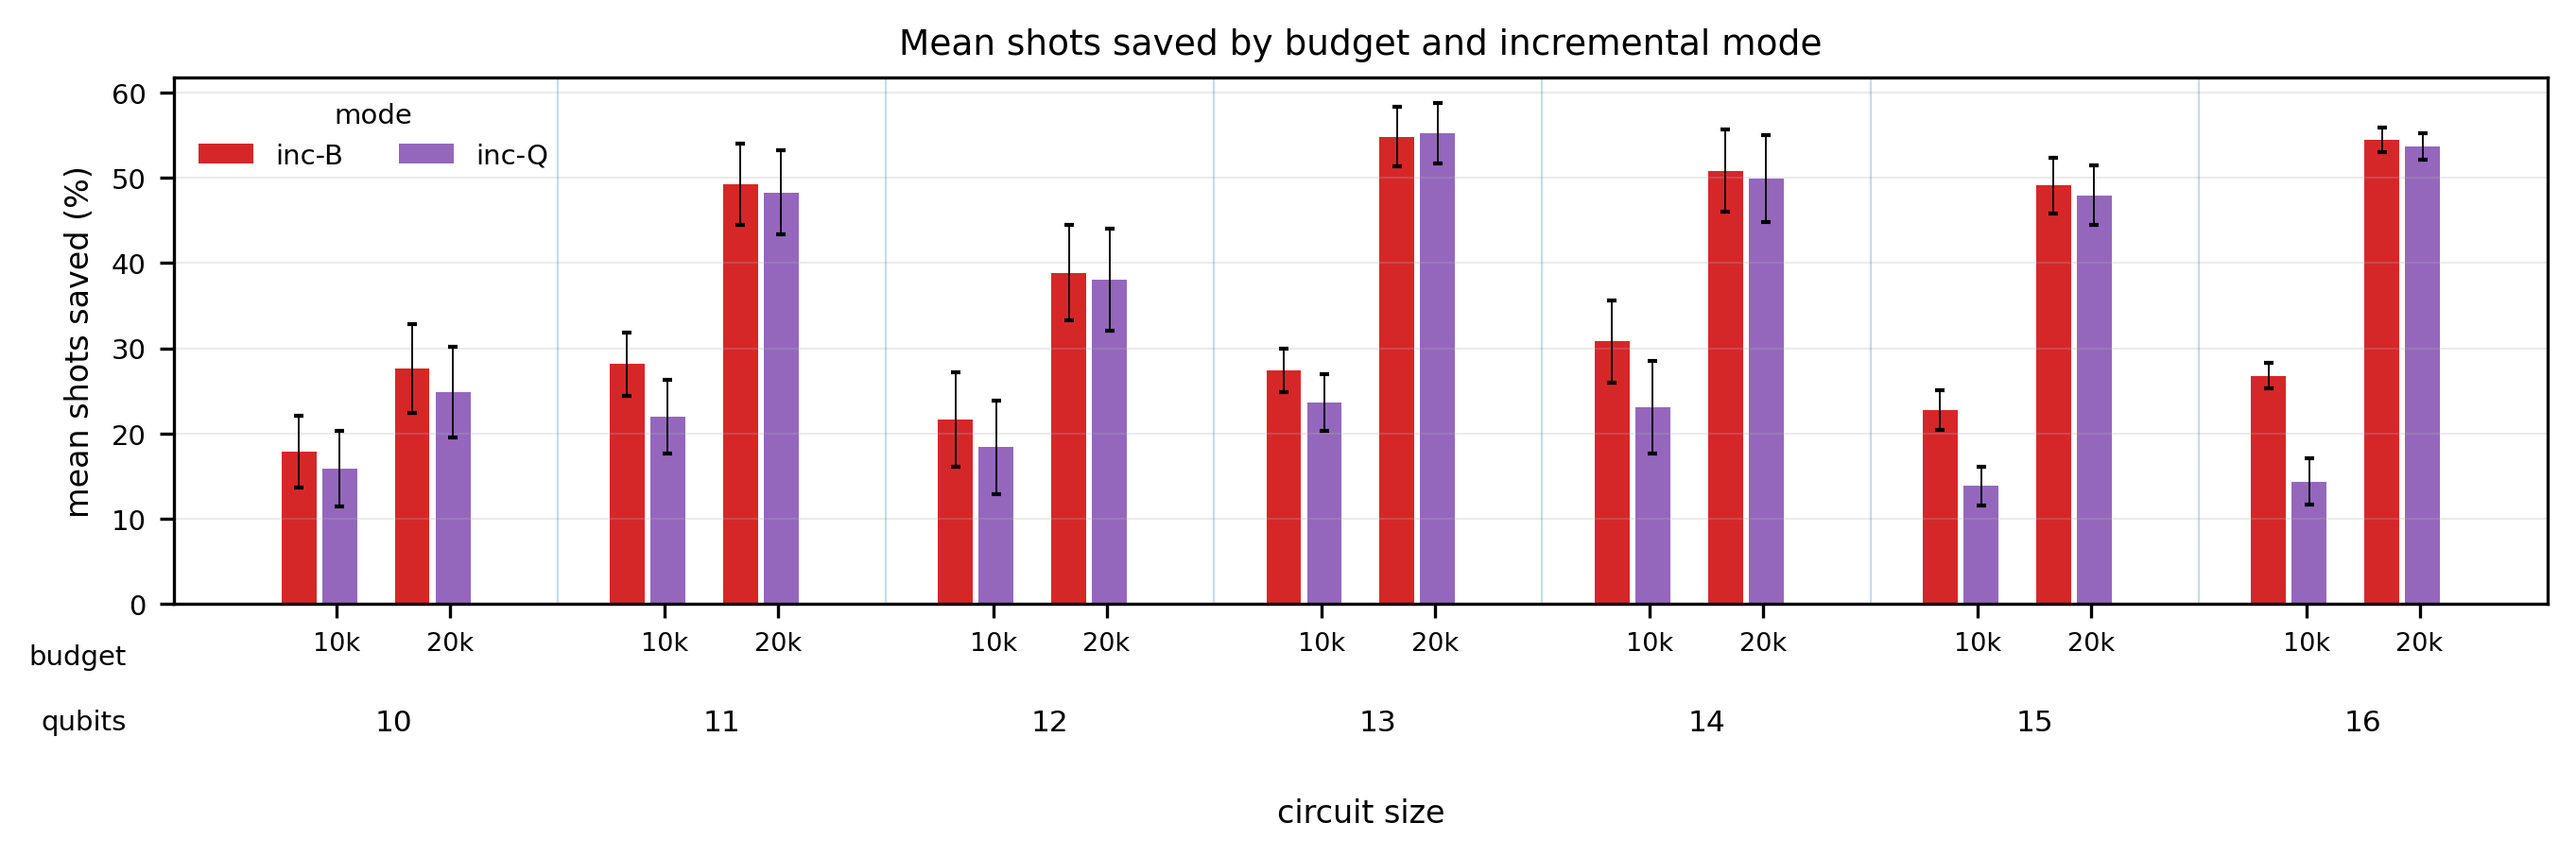

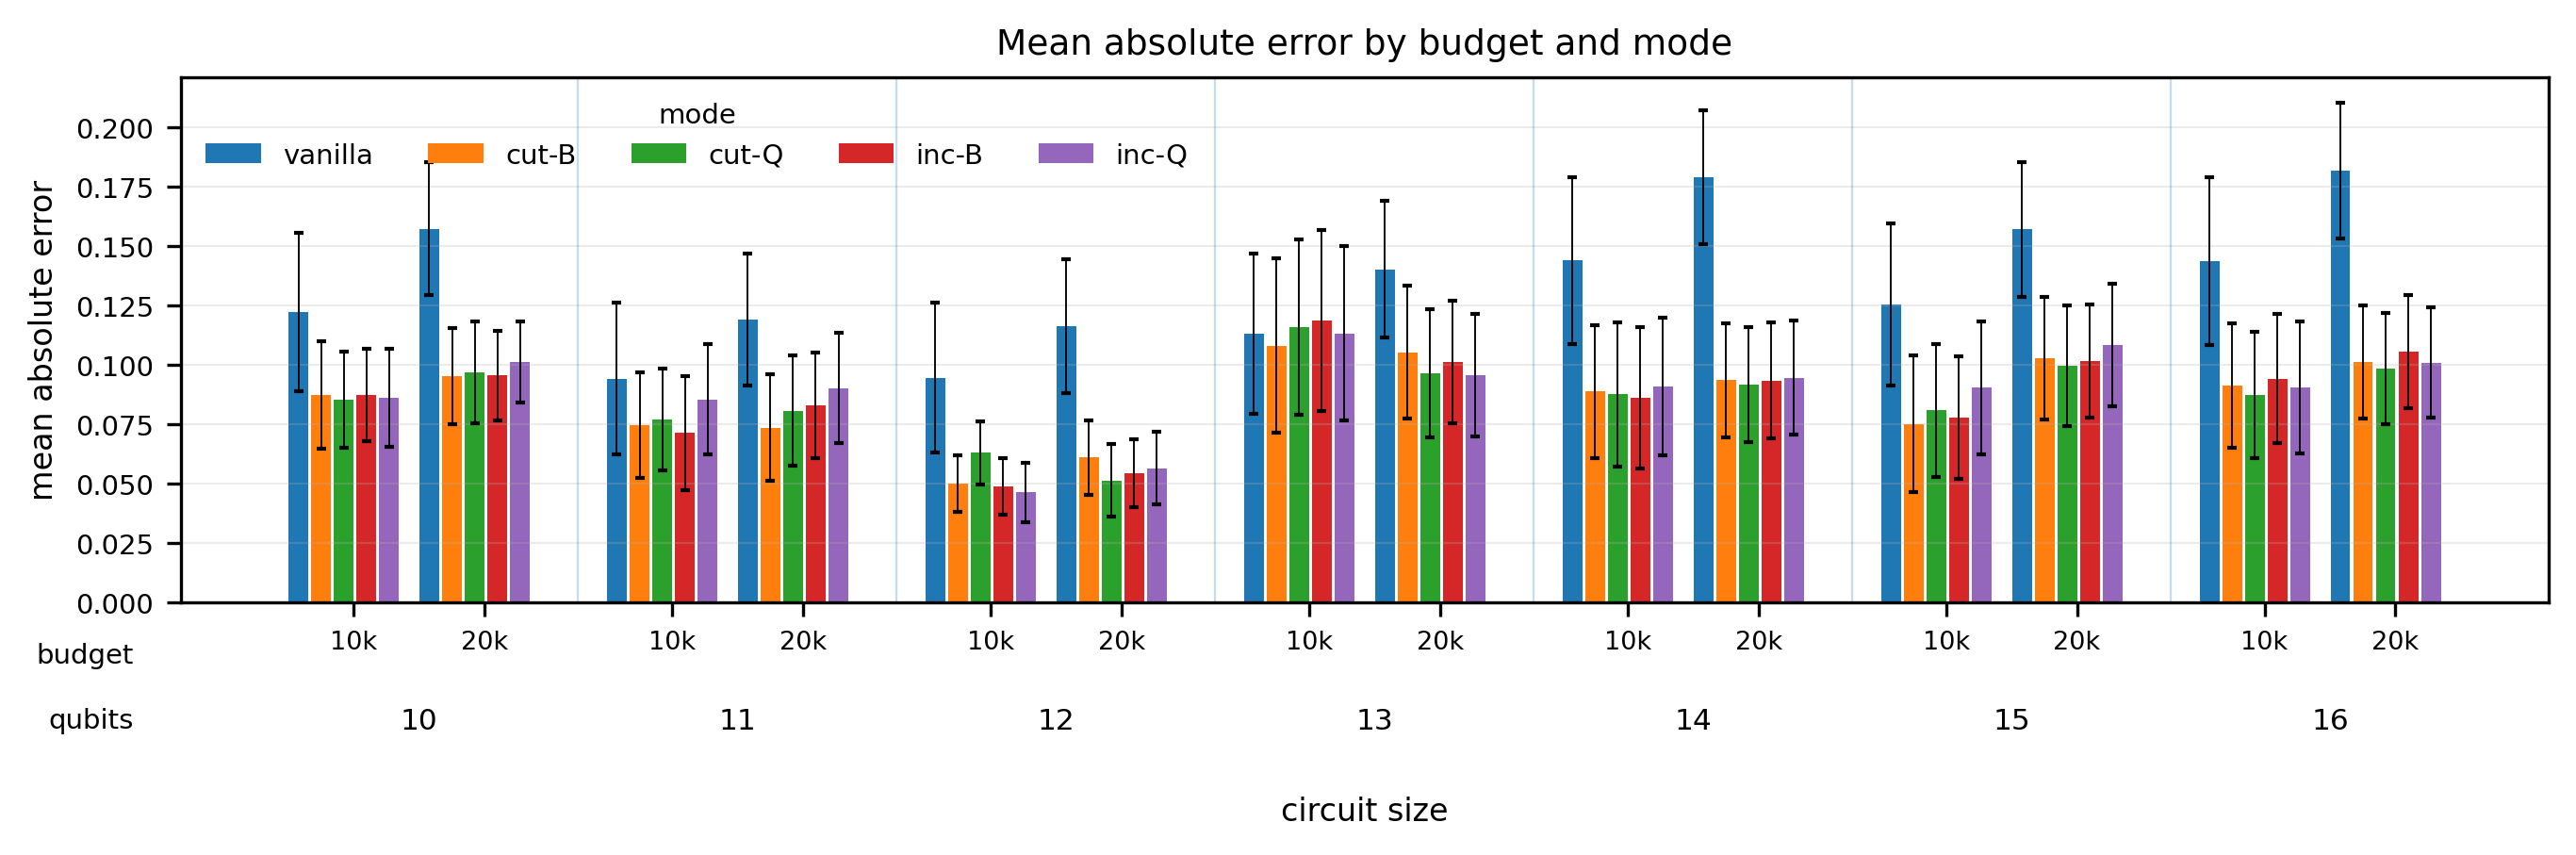

In [628]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
baseline_mode = "noisy_vanilla"
size_col = "circuit_qubits"
budget_col = "budget"

# Choose aggregation method:
#   "median" -> bar height = median, whiskers = IQR
#   "mean"   -> bar height = mean, whiskers = SEM or STD
AGG_METHOD = "mean"      # choose: "median" or "mean"
MEAN_WHISKER_TYPE = "sem"  # choose: "sem" or "std", used only if AGG_METHOD = "mean"

# Toggle vanilla in the absolute-error plot
INCLUDE_VANILLA_IN_ERROR_PLOT = True

required_cols = {size_col, budget_col, "mode", "shots_executed", "absolute_error"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

if AGG_METHOD not in {"median", "mean"}:
    raise ValueError("AGG_METHOD must be 'median' or 'mean'")

if MEAN_WHISKER_TYPE not in {"sem", "std"}:
    raise ValueError("MEAN_WHISKER_TYPE must be 'sem' or 'std'")

plot_df = df[df["mode"].isin(MODES)].copy()

if baseline_mode not in plot_df["mode"].unique():
    raise ValueError(f"Baseline mode '{baseline_mode}' not found in df['mode']")


# ------------------------------------------------------------
# Mode lists
# ------------------------------------------------------------
non_vanilla_modes = [
    "cut_divided_budget",
    "cut_qubit_prop",
    "cut_incremental_budget",
    "cut_incremental_qubit_prop",
]
non_vanilla_modes = [m for m in non_vanilla_modes if m in plot_df["mode"].unique()]

for m in MODES:
    if m != baseline_mode and m not in non_vanilla_modes and m in plot_df["mode"].unique():
        non_vanilla_modes.append(m)

if INCLUDE_VANILLA_IN_ERROR_PLOT:
    error_mode_order = [baseline_mode] + non_vanilla_modes
else:
    error_mode_order = non_vanilla_modes.copy()

# Shots-saved plot: incremental modes only
shots_mode_order = [
    "cut_incremental_budget",
    "cut_incremental_qubit_prop",
]
shots_mode_order = [m for m in shots_mode_order if m in plot_df["mode"].unique()]

if not error_mode_order:
    raise ValueError("No modes found for the error plot.")

if not shots_mode_order:
    raise ValueError("No incremental modes found for the shots-saved plot.")


# ------------------------------------------------------------
# Labels and colors
# ------------------------------------------------------------
mode_label = {
    "noisy_vanilla": "vanilla",
    "cut_divided_budget": "cut-B",
    "cut_qubit_prop": "cut-Q",
    "cut_incremental_budget": "inc-B",
    "cut_incremental_qubit_prop": "inc-Q",
}

for m in set(error_mode_order + shots_mode_order):
    mode_label.setdefault(m, m)

color_map = {
    "noisy_vanilla": "tab:blue",
    "cut_divided_budget": "tab:orange",
    "cut_qubit_prop": "tab:green",
    "cut_incremental_budget": "tab:red",
    "cut_incremental_qubit_prop": "tab:purple",
}

default_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for i, mode in enumerate(error_mode_order + shots_mode_order):
    if mode not in color_map:
        color_map[mode] = default_cycle[i % len(default_cycle)]


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def budget_to_number(v):
    """Convert budgets such as 5000, '5000', or '5k' to numeric values."""
    if isinstance(v, (int, float, np.integer, np.floating)):
        return float(v)

    s = str(v).lower().replace("shots", "").replace("_", "").strip()

    if s.endswith("k"):
        return float(s[:-1]) * 1000

    return float(s)


def budget_sort_key(v):
    try:
        return (0, budget_to_number(v))
    except Exception:
        return (1, str(v))


def format_budget(v):
    """Compact budget labels."""
    try:
        x = budget_to_number(v)
        if x >= 1000 and x % 1000 == 0:
            return f"{int(x // 1000)}k"
        return str(int(x))
    except Exception:
        return str(v)


def summarize_values(dataframe, value_col):
    """
    Summarize values according to AGG_METHOD.

    If AGG_METHOD == "median":
        center = median
        whiskers = IQR, i.e. [q25, q75]

    If AGG_METHOD == "mean":
        center = mean
        whiskers = mean ± SEM or mean ± STD
    """
    group_cols = [size_col, budget_col, "mode"]

    if AGG_METHOD == "median":
        summary = (
            dataframe
            .groupby(group_cols, as_index=False)
            .agg(
                center=(value_col, "median"),
                q1=(value_col, lambda s: s.quantile(0.25)),
                q3=(value_col, lambda s: s.quantile(0.75)),
            )
        )

    elif AGG_METHOD == "mean":
        summary = (
            dataframe
            .groupby(group_cols, as_index=False)
            .agg(
                center=(value_col, "mean"),
                std=(value_col, "std"),
                n=(value_col, "count"),
            )
        )

        summary["std"] = summary["std"].fillna(0)

        if MEAN_WHISKER_TYPE == "std":
            spread = summary["std"]
        elif MEAN_WHISKER_TYPE == "sem":
            spread = summary["std"] / np.sqrt(summary["n"].clip(lower=1))

        summary["q1"] = summary["center"] - spread
        summary["q3"] = summary["center"] + spread

    return summary


plot_df["_budget_numeric"] = plot_df[budget_col].apply(budget_to_number)

budget_order = sorted(plot_df[budget_col].dropna().unique(), key=budget_sort_key)
qubit_order = sorted(plot_df[size_col].dropna().unique())

if AGG_METHOD == "median":
    whisker_label = "IQR"
else:
    whisker_label = MEAN_WHISKER_TYPE.upper()

print("Aggregation:", AGG_METHOD)
print("Whiskers:", whisker_label)
print("Budgets found:", [format_budget(b) for b in budget_order])
print("Qubit sizes found:", qubit_order)
print("Modes in shots-saved plot:", shots_mode_order)
print("Modes in error plot:", error_mode_order)


# ------------------------------------------------------------
# Shots-saved summary
#
# Only incremental modes are shown here.
#
# shots saved (%) = (budget - shots_executed) / budget * 100
# ------------------------------------------------------------
shots_source = plot_df[plot_df["mode"].isin(shots_mode_order)].copy()

shots_source["shots_saved_pct"] = (
    shots_source["_budget_numeric"]
    .sub(shots_source["shots_executed"])
    .div(shots_source["_budget_numeric"])
    .mul(100)
)

shots_summary = summarize_values(
    shots_source,
    value_col="shots_saved_pct",
)


# ------------------------------------------------------------
# Absolute-error summary
#
# Includes vanilla only if INCLUDE_VANILLA_IN_ERROR_PLOT = True.
# ------------------------------------------------------------
error_source = plot_df[plot_df["mode"].isin(error_mode_order)].copy()
error_source["abs_error"] = error_source["absolute_error"].abs()

error_summary = summarize_values(
    error_source,
    value_col="abs_error",
)


# ------------------------------------------------------------
# Plotting function
# ------------------------------------------------------------
def plot_budget_grouped_bars(
    summary_df,
    modes_to_plot,
    ylabel,
    title,
    output_base,
    ylim=None,
):
    fig, ax = plt.subplots(figsize=(9.2, 3.2), dpi=300)

    n_modes = len(modes_to_plot)
    n_budgets = len(budget_order)

    bar_w = 0.060
    bar_gap = 0.010
    budget_gap = 0.065
    qubit_gap = 0.240

    budget_w = n_modes * bar_w + (n_modes - 1) * bar_gap
    qubit_w = n_budgets * budget_w + (n_budgets - 1) * budget_gap

    qubit_centers = []
    budget_centers = []
    budget_texts = []

    for m_idx, mode in enumerate(modes_to_plot):
        xs = []
        ys = []
        err_low = []
        err_high = []

        for q_idx, q in enumerate(qubit_order):
            q_start = q_idx * (qubit_w + qubit_gap)

            if m_idx == 0:
                qubit_centers.append(q_start + qubit_w / 2)

            for b_idx, budget in enumerate(budget_order):
                b_start = q_start + b_idx * (budget_w + budget_gap)
                x = b_start + m_idx * (bar_w + bar_gap)

                if m_idx == 0:
                    budget_centers.append(b_start + budget_w / 2)
                    budget_texts.append(format_budget(budget))

                sub = summary_df[
                    (summary_df[size_col] == q)
                    & (summary_df[budget_col] == budget)
                    & (summary_df["mode"] == mode)
                ]

                if sub.empty:
                    xs.append(x)
                    ys.append(np.nan)
                    err_low.append(0)
                    err_high.append(0)
                    continue

                row = sub.iloc[0]
                center = row["center"]

                xs.append(x)
                ys.append(center)
                err_low.append(max(center - row["q1"], 0))
                err_high.append(max(row["q3"] - center, 0))

        ax.bar(
            xs,
            ys,
            width=bar_w,
            color=color_map[mode],
            label=mode_label[mode],
            yerr=[err_low, err_high],
            capsize=1.1,
            error_kw={"linewidth": 0.45},
        )

    # First x-axis tier: budget labels
    ax.set_xticks(budget_centers)
    ax.set_xticklabels(budget_texts, fontsize=6.5)

    # Second x-axis tier: qubit labels
    trans = ax.get_xaxis_transform()

    for q, center in zip(qubit_order, qubit_centers):
        ax.text(
            center,
            -0.20,
            str(q),
            ha="center",
            va="top",
            fontsize=7.5,
            transform=trans,
            clip_on=False,
        )

    # Separator lines between qubit groups
    for q_idx in range(1, len(qubit_order)):
        x_sep = q_idx * (qubit_w + qubit_gap) - qubit_gap / 2
        ax.axvline(x_sep, linewidth=0.55, alpha=0.25)

    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.tick_params(axis="y", labelsize=7)
    ax.grid(axis="y", alpha=0.25, linewidth=0.5)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.text(
        -0.02,
        -0.075,
        "budget",
        ha="right",
        va="top",
        fontsize=7,
        transform=ax.transAxes,
        clip_on=False,
    )

    ax.text(
        -0.02,
        -0.20,
        "qubits",
        ha="right",
        va="top",
        fontsize=7,
        transform=ax.transAxes,
        clip_on=False,
    )

    ax.set_xlabel("circuit size", fontsize=8, labelpad=36)

    ax.legend(
        title="mode",
        title_fontsize=7,
        fontsize=7,
        ncol=len(modes_to_plot),
        loc="upper left",
        frameon=False,
    )

    fig.subplots_adjust(
        bottom=0.30,
        top=0.88,
        left=0.08,
        right=0.99,
    )

    #fig.savefig(f"{output_base}.pdf", bbox_inches="tight")
    #fig.savefig(f"{output_base}.png", bbox_inches="tight")
    plt.show()


# ------------------------------------------------------------
# Create the two separate plots
# ------------------------------------------------------------
agg_label = AGG_METHOD.capitalize()

plot_budget_grouped_bars(
    shots_summary,
    modes_to_plot=shots_mode_order,
    ylabel=f"{AGG_METHOD} shots saved (%)",
    title=f"{agg_label} shots saved by budget and incremental mode",
    output_base=f"{AGG_METHOD}_shots_saved_grouped_by_budget_incremental_only",
)

error_output_suffix = "with_vanilla" if INCLUDE_VANILLA_IN_ERROR_PLOT else "without_vanilla"

plot_budget_grouped_bars(
    error_summary,
    modes_to_plot=error_mode_order,
    ylabel=f"{AGG_METHOD} absolute error",
    title=f"{agg_label} absolute error by budget and mode",
    output_base=f"{AGG_METHOD}_absolute_error_grouped_by_budget_{error_output_suffix}",
)